# 只有 50 帧时，估计 $\sigma^2$ 与 $\sigma^2/\theta$

真实数据中最短的轨迹片段只有 **50 帧**，所以所有估计都必须在 50 帧内完成。本 notebook 把每条长轨迹切成互不重叠的 50 帧片段，**每个片段单独估计**，模拟“只有一段 50 帧轨迹”的情况。目标量为

$$
\sigma^2 \qquad\text{和}\qquad R\equiv\frac{\sigma^2}{\theta}=2\,\mathrm{Var}_{\text{stat}}(X).
$$

在 $\Delta=0.02$ 下，50 帧只相当于 1 个时间单位，而松弛时间 $1/\theta$ 在 0.1–1 之间。**一个片段里只包含 1–10 个松弛时间**，这带来两个问题：

1. **有限窗口偏差**：减去片段均值后的样本方差会系统性低估平稳方差，$\theta$ 越小越严重；
2. **信息量有限**：独立样本很少，任何方法的单片段误差都有一个下限。

本 notebook 比较经典方法与带偏差校正的方法，并给出误差随“每段包含的松弛时间数 $\theta L\Delta$”的变化，帮助判断什么时候 50 帧的估计可信。

> **关于 SPINN**：当前 SPINN 的配置需要 100 帧的片段（50 帧编码 + 50 帧预测），**无法直接用于只有 50 帧的轨迹**。下表中带 `*` 的 SPINN 结果来自长轨迹上的推断，用到了片段以外的上下文，只能作为参考上限。要真正用于 50 帧轨迹，需要用 25 + 25 的窗口重新训练。
>
> 运行前提：与前两个探索 notebook 相同，需先运行 `SPINN_OU_demo.ipynb`。数据与它们相同（每个情景 32 条独立测试轨迹，$\mu_i$ 各不相同），切成 50 帧片段后每个情景共 640 个片段。在 4 核 CPU 上约 2 分钟跑完。

## 0. 环境与配置

网络配置必须与 `SPINN_OU_demo.ipynb` 训练时一致（`QUICK = True` 的设置）。

In [1]:
import os, sys, time, types, argparse, warnings, itertools
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath('.')
while not os.path.exists(os.path.join(REPO_ROOT, 'TrainJumpSDEsTransform.py')):
    parent = os.path.dirname(REPO_ROOT)
    if parent == REPO_ROOT:
        raise FileNotFoundError('请把 notebook 放在 SPINN 仓库内运行')
    REPO_ROOT = parent
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

try:
    import pkg_resources  # noqa: F401
except ImportError:  # 新版 setuptools 已移除 pkg_resources，仓库的 robust_loss_pytorch 需要它
    _shim = types.ModuleType('pkg_resources')
    def _resource_stream(package, resource):
        return open(os.path.join(os.path.dirname(sys.modules[package].__file__), resource), 'rb')
    _shim.resource_stream = _resource_stream
    sys.modules['pkg_resources'] = _shim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import uniform_filter1d

from model.JumpSDEsTrans import JumpSDEsTransformer
from TrainJumpSDEsTransform import (DatasetTracks, generate_dataset_torch, train_sigma, train_velocity,
                                    transform, load)
from utils.csv2npy import v_normalize_batch_encoder

torch.set_num_threads(os.cpu_count())
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

C_TRUE = '#3a3a38'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 1.6,
                     'font.size': 9, 'legend.frameon': False, 'axes.unicode_minus': False})

# 与 SPINN_OU_demo.ipynb（QUICK = True）相同的网络配置
cfg = argparse.Namespace(
    epochs=12, epochs_VDt=6, batch_size=20, lr=1e-3, seed=0, clip_grad=5.0, scale=0.375, warmup_steps=100,
    RESUME=False, default_enc_nn=((64, 'gelu'), (64, 'gelu')), hidden_size=64, layers=2, h_dim=32,
    d_model=64, n_heads=4, enc_layers=2, dropout=0.25, is_var_head=True, in_dim=2, out_dim=2,
    pred_length=50, encoder_length=50, beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0,
    noise_adding=0.0, sample_rates=1.0, sample_nums=0,
    dload='./model_dir/ou_demo', save_name='ou-demo', model_name='ou-demo.pth', device=DEVICE,
)
for f in ['ou-demo.pth', 'ou-demo-var.pth', 'ou-demo-vel.pth']:
    if not os.path.exists(os.path.join(cfg.dload, f)):
        raise FileNotFoundError(f'找不到 {cfg.dload}/{f}，请先完整运行 SPINN_OU_demo.ipynb')

model = JumpSDEsTransformer(in_dim=cfg.in_dim, out_dim=cfg.in_dim, encoding_len=cfg.encoder_length,
                            h_dim=cfg.h_dim, default_enc_nn=cfg.default_enc_nn, hidden_dim=cfg.hidden_size,
                            layers=cfg.layers, d_model=cfg.d_model, n_head=cfg.n_heads, layers_enc=cfg.enc_layers,
                            dropout=cfg.dropout, device=cfg.device).to(cfg.device)
load(model, cfg.dload, cfg.model_name)
L_ENC, L_PRED = cfg.encoder_length, cfg.pred_length
WIN = L_ENC + L_PRED
print('模型已加载 | device:', DEVICE)

模型已加载 | device: cpu


## 1. 独立测试数据：$\mu_i$ 各不相同的时变 OU 轨迹

模拟参数与 `SPINN_OU_demo.ipynb` 相同（$\Delta=0.02$、每条轨迹 1000 帧、6 种 $\theta_t/\sigma_t$ 组合），使用精确离散化：

$$
X_{n+1} = \mu_i + (X_n-\mu_i)\,e^{-\theta_n\Delta} + \sigma_n\sqrt{\tfrac{1-e^{-2\theta_n\Delta}}{2\theta_n}}\;\xi_n .
$$

这里用**新的随机种子**生成每个情景 32 条轨迹。它们既没有参与训练，也没有在 `SPINN_OU_demo.ipynb` 里被用来挑选方法。每条轨迹的平衡位置 $\mu_i = (2,-1) + \delta_i$，$\delta_i\sim\mathcal N(0, 1^2)$。

In [2]:
DT, T_LEN, N_EVAL = 0.02, 1000, 32
MU0 = np.array([2.0, -1.0])
t_grid = np.arange(T_LEN) * DT
T_END = t_grid[-1] + DT
square_wave = lambda t, period: (np.floor(t / (period / 2)) % 2).astype(float)

SCENARIOS = {
    'A 常数基准':        dict(en='A: constant θ, σ',         theta=lambda t: 4.0 + 0 * t, sigma=lambda t: 1.0 + 0 * t),
    'B σ 阶跃':          dict(en='B: σ step',                theta=lambda t: 4.0 + 0 * t, sigma=lambda t: np.where(t < T_END / 2, 0.6, 1.5)),
    'C σ 正弦':          dict(en='C: σ sine',                theta=lambda t: 4.0 + 0 * t, sigma=lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / 10)),
    'D θ 线性增加':      dict(en='D: θ ramp',                theta=lambda t: 1.0 + 9.0 * t / T_END, sigma=lambda t: 1.0 + 0 * t),
    'E θ 正弦 + σ 线性': dict(en='E: θ sine + σ ramp',       theta=lambda t: 5.0 + 3.0 * np.sin(2 * np.pi * t / 8), sigma=lambda t: 0.5 + 1.0 * t / T_END),
    'F θ/σ 反相切换':     dict(en='F: θ/σ anti-phase switch', theta=lambda t: 2.0 + 6.0 * square_wave(t, 10), sigma=lambda t: 1.4 - 0.7 * square_wave(t, 10)),
}
names = list(SCENARIOS)
EN = {k: v['en'] for k, v in SCENARIOS.items()}

def simulate_ou(theta_fn, sigma_fn, n_tracks, rng, mu_spread=1.0):
    th, sg = theta_fn(t_grid), sigma_fn(t_grid)
    a = np.exp(-th * DT)
    sd = sg * np.sqrt((1 - a ** 2) / (2 * th))
    mu = MU0 + mu_spread * rng.standard_normal((n_tracks, 1, 2))          # 每条轨迹自己的 μ_i
    X = np.empty((n_tracks, T_LEN, 2))
    X[:, 0] = mu[:, 0] + sg[0] / np.sqrt(2 * th[0]) * rng.standard_normal((n_tracks, 2))
    for n in range(T_LEN - 1):
        X[:, n + 1] = mu[:, 0] + (X[:, n] - mu[:, 0]) * a[n] + sd[n] * rng.standard_normal((n_tracks, 2))
    return dict(X=X, mu=mu, theta=th, sigma=sg, sigma_eff=sd / np.sqrt(DT))

rng = np.random.default_rng(2025)
DATA = {name: simulate_ou(sc['theta'], sc['sigma'], N_EVAL, rng) for name, sc in SCENARIOS.items()}
print({k: v['X'].shape for k, v in DATA.items()})

{'A 常数基准': (32, 1000, 2), 'B σ 阶跃': (32, 1000, 2), 'C σ 正弦': (32, 1000, 2), 'D θ 线性增加': (32, 1000, 2), 'E θ 正弦 + σ 线性': (32, 1000, 2), 'F θ/σ 反相切换': (32, 1000, 2)}


## 2. SPINN 推断

与 `SPINN_OU_demo.ipynb` 第 3、6 节完全相同：先切成 regular + head 片段并归一化，再依次调用仓库的 `transform`、`train_sigma(is_train=False)`、`train_velocity(is_train=False)`，最后反归一化并拼回整条轨迹。得到每条轨迹、每一帧的漂移 $v^{(1)}$ 和扩散 $s^{(1)}$。

In [3]:
def segment(arr, is_head=False):
    if is_head:
        arr = np.concatenate([np.repeat(arr[:, :1], L_PRED, axis=1), arr[:, :-L_PRED]], axis=1)
    starts = np.arange(0, arr.shape[1] - WIN + 1, WIN)
    return np.concatenate([arr[:, s:s + WIN][:, None] for s in starts], axis=1).reshape(-1, WIN, *arr.shape[2:])

def build_segments(X):
    N = X.shape[0]
    frame = np.broadcast_to(np.arange(T_LEN), (N, T_LEN))
    track = np.broadcast_to(np.arange(N)[:, None], (N, T_LEN))
    out = {}
    for kind, head in [('regular', False), ('head', True)]:
        seg_norm, s = v_normalize_batch_encoder(segment(X, head), encoder_len=L_ENC)
        out[kind] = dict(x=seg_norm.astype(np.float32), norm=s, frame=segment(frame, head), track=segment(track, head))
    return out

def spinn_infer(seg_x):
    ds = DatasetTracks(seg_x, cfg, sample_rate=1.0)
    _, test_ds = generate_dataset_torch(ds, seed=cfg.seed, train_prob=1e-6)
    _, y1, _, _ = transform(test_ds, model, cfg)
    s_ds, model_s = train_sigma(test_ds, model, cfg, is_train=False)
    _, s1, _, _ = transform(s_ds, model_s, cfg)
    v_ds, model_v = train_velocity(test_ds, model, cfg, is_train=False)
    _, v1, _, _ = transform(v_ds, model_v, cfg)
    tb = lambda a: a.transpose(1, 0, 2)[:, -L_PRED:]
    return dict(v1=tb(v1), s1=tb(s1))

def infer_tracks(X):
    segs, N = build_segments(X), X.shape[0]
    full = {k: np.full((N, T_LEN, 2), np.nan) for k in ['v1', 's1']}
    for kind in ['regular', 'head']:
        seg = segs[kind]
        o = spinn_infer(seg['x'])
        s = seg['norm'].reshape(1, 1, 2)
        fr, tr = seg['frame'][:, L_ENC:], seg['track'][:, L_ENC:]
        full['v1'][tr, fr] = o['v1'] * s
        full['s1'][tr, fr] = o['s1'] * s ** 2
    return full

t0 = time.time()
RES = {name: infer_tracks(DATA[name]['X']) for name in names}
print(f'SPINN 推断完成，用时 {time.time() - t0:.0f}s')

SPINN 推断完成，用时 46s


## 3. 切成 50 帧片段

每条 1000 帧的测试轨迹切成 20 个互不重叠的 50 帧片段。每个片段的真值取片段内的平均：$\bar\sigma^2$ 与 $\overline{\sigma^2/\theta}$（参数在片段内变化不大）。

指标（对所有片段取中位数）：

- $|\log|$ 误差：$\operatorname{median}|\ln(\hat q/q)|$，例如 0.10 ≈ 10% 的典型误差，0.40 ≈ 1.5 倍；
- 偏差：$\operatorname{median}\ln(\hat q/q)$，负数表示系统性低估。

In [4]:
L = 50
def to_segments(A):
    """(N,T,...) -> (N*T/L, L, ...)"""
    N, T = A.shape[:2]
    return A[:, :T // L * L].reshape(N * (T // L), L, *A.shape[2:])

SEG = {}
for name in names:
    d = DATA[name]
    full = lambda v: np.broadcast_to(v, (N_EVAL, T_LEN))
    SEG[name] = dict(X=to_segments(d['X']),
                     s1=to_segments(RES[name]['s1']),
                     R=to_segments(full(d['sigma'] ** 2 / d['theta'])).mean(axis=1),
                     S2=to_segments(full(d['sigma'] ** 2)).mean(axis=1),
                     theta=to_segments(full(d['theta'])).mean(axis=1),
                     t_mid=to_segments(full(t_grid)).mean(axis=1))
print('每个情景的片段数：', SEG[names[0]]['X'].shape[0], '| 片段形状：', SEG[names[0]]['X'].shape[1:])

def log_err(est, true):
    r = np.log(np.clip(est, 1e-12, None) / true)
    return {'|log| 误差': np.median(np.abs(r)), '偏差 (median log)': np.median(r)}

def table(EST, key, methods):
    rows = [dict(情景=n, 方法=m, **log_err(EST[n][m], SEG[n][key])) for n in names for m in methods]
    df = pd.DataFrame(rows)
    out = {}
    for col in ['|log| 误差', '偏差 (median log)']:
        p = df.pivot(index='情景', columns='方法', values=col)[methods]
        p.loc['6 个情景平均'] = p.mean()
        out[col] = p
    return out

每个情景的片段数： 640 | 片段形状： (50, 2)


## 4. 有限窗口偏差有多大？

对离散 AR(1)（$\varphi=e^{-\theta\Delta}$）的 $n$ 点片段，减去片段均值后的样本方差（除以 $n-1$）满足

$$
\mathbb E[S^2] = V_{\text{stat}}\cdot f(\theta, n),\qquad
f(\theta,n)=\frac{n}{n-1}\left[1-\frac1n\Big(1+2\sum_{k=1}^{n-1}\big(1-\tfrac kn\big)\varphi^k\Big)\right].
$$

下图画出 $n=50$ 时的 $f$。本实验中 $\theta\in[1,10]$，对应的低估程度为 30%–80%。直接用 $2S^2$ 估计 $\sigma^2/\theta$ 会严重偏低。

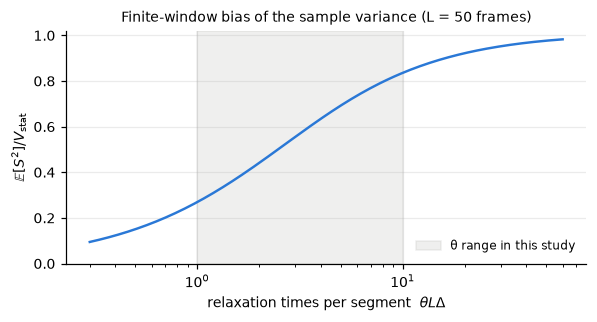

In [5]:
def f_window(theta, n=L):
    phi = np.exp(-np.asarray(theta, float)[..., None] * DT)
    k = np.arange(1, n)
    s = np.sum((1 - k / n) * phi ** k, axis=-1)
    return (1 - (1 + 2 * s) / n) * n / (n - 1)

th_axis = np.exp(np.linspace(np.log(0.3), np.log(60), 200))
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(th_axis * L * DT, f_window(th_axis), color='#2a78d6')
ax.axvspan(1 * L * DT, 10 * L * DT, color='#b0b0aa', alpha=0.2, label='θ range in this study')
ax.set_xscale('log'); ax.set_ylim(0, 1.02)
ax.set_xlabel(r'relaxation times per segment  $\theta L\Delta$'); ax.set_ylabel(r'$\mathbb{E}[S^2]/V_{\rm stat}$')
ax.set_title('Finite-window bias of the sample variance (L = 50 frames)', fontsize=9); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 5. 候选方法

所有方法都只使用单个 50 帧片段（两个维度共享 $\theta,\sigma$，各自的均值 $\mu$ 未知）。

| 方法 | $\hat\sigma^2$ | $\hat R=\hat\sigma^2/\hat\theta$ |
|---|---|---|
| `均分 (未校正)` | — | $2S^2$ |
| `实现方差 RV` | $\frac{1}{(L-1)\Delta}\sum(\Delta X)^2$ | — |
| `MSD 拟合` | 拟合 $\mathrm{MSD}(\tau)=R(1-e^{-\theta\tau\Delta})$，$\tau=1..25$，$\hat\sigma^2=\hat R\hat\theta$ | 同左 |
| `AR(1)-Kendall` | — | 片段内 AR(1) 回归，Kendall 校正 $\hat\varphi$，$\hat R=2\hat s^2/(1-\hat\varphi^2)$ |
| `精确 MLE` | OU 精确似然的最大似然估计（对 $\theta$ 做网格剖面，$\mu,\sigma^2$ 有闭式解） | 同左 |
| **`锚定均分`** | RV 经 $\hat\theta$ 做离散化校正 | 见下 |
| `锚定均分 (SPINN*)` | 同上，但单步方差用 SPINN 的 $s^{(1)}$（有上下文，仅作参考） | 同左 |
| `锚定均分 (真 σ², 参考)` | 用真实单步方差，表示“$\sigma^2$ 完全已知”时的误差下限参考 | 同左 |

**锚定均分**的思路：单步方差 $s$（来自 RV，很准）和样本方差 $S^2$（信息少、有偏）满足

$$
\mathbb E[S^2] = \frac{s}{1-e^{-2\theta\Delta}}\,f(\theta,L),
$$

右边关于 $\theta$ 单调，所以令 $S^2$ 等于右边即可解出 $\hat\theta$（查表插值）。然后

$$
\hat R = \frac{2s}{1-e^{-2\hat\theta\Delta}},\qquad \hat\sigma^2=\hat R\,\hat\theta .
$$

它用准确的 $\sigma^2$ 信息“锚定”方差，并解析地修正了有限窗口偏差。

In [6]:
from scipy.optimize import least_squares

# 锚定均分：S²/s = h(θ) = f(θ,L) / (1 - e^{-2θΔ})，在 θ∈[0.02,150] 上单调递减
TH_TAB = np.exp(np.linspace(np.log(0.02), np.log(150), 3000))
H_TAB = f_window(TH_TAB) / (1 - np.exp(-2 * TH_TAB * DT))
assert np.all(np.diff(H_TAB) < 0)

def anchored(X, s_step):
    """X: (M,L,2) 片段；s_step: (M,) 单步方差。返回 R̂, σ̂², θ̂"""
    S2 = X.var(axis=1, ddof=1).mean(axis=1)
    ratio = np.clip(S2 / s_step, H_TAB[-1], H_TAB[0])
    th = np.interp(ratio, H_TAB[::-1], TH_TAB[::-1])
    R = 2 * s_step / (1 - np.exp(-2 * th * DT))
    return R, R * th, th

def ar1_kendall(X):
    x0, x1 = X[:, :-1], X[:, 1:]
    x0c, x1c = x0 - x0.mean(axis=1, keepdims=True), x1 - x1.mean(axis=1, keepdims=True)
    phi = ((x0c * x1c).sum(axis=1) / (x0c ** 2).sum(axis=1)).mean(axis=1)
    n = X.shape[1] - 1
    s2 = ((x1c - phi[:, None, None] * x0c) ** 2).sum(axis=(1, 2)) / (2 * (n - 2))
    phi_k = np.clip((n * phi + 1) / (n - 3), 0.05, 0.995)
    return 2 * s2 / (1 - phi_k ** 2)

TH_MLE = np.exp(np.linspace(np.log(0.05), np.log(200), 400))
def ou_mle(X):
    """OU 精确似然：两维共享 θ,σ，各自 μ；对 θ 网格剖面。返回 R̂, σ̂²"""
    M, Ln, D = X.shape; n = Ln - 1
    x0, xs, xn = X[:, 0], X[:, :-1], X[:, 1:]
    best = np.full(M, -np.inf); R = np.zeros(M); S2 = np.zeros(M)
    for th in TH_MLE:
        phi = np.exp(-th * DT); c = 1 - phi ** 2
        e = xn - phi * xs
        mu = (c * x0 + (1 - phi) * e.sum(axis=1)) / (c + n * (1 - phi) ** 2)
        ss = c * (x0 - mu) ** 2 + ((e - (1 - phi) * mu[:, None]) ** 2).sum(axis=1)
        v = ss.sum(axis=1) / (D * (n + 1) * c)
        ll = -0.5 * D * (n + 1) * np.log(v) - 0.5 * D * n * np.log(c)
        m = ll > best
        best[m], R[m], S2[m] = ll[m], 2 * v[m], 2 * th * v[m]
    return R, S2

def msd_fit(X, taus=np.arange(1, 26)):
    msd = np.stack([((X[:, t:] - X[:, :-t]) ** 2).mean(axis=(1, 2)) for t in taus], axis=1)
    R, S2 = np.empty(len(X)), np.empty(len(X))
    for i, m in enumerate(msd):
        res = lambda p: (np.exp(p[0]) * (1 - np.exp(-np.exp(p[1]) * taus * DT)) - m) / m
        p = least_squares(res, [np.log(m[-1]), np.log(max(m[0] / (m[-1] * DT), 0.1))],
                          bounds=([-12, np.log(0.05)], [5, np.log(500)])).x
        R[i], S2[i] = np.exp(p[0]), np.exp(p[0] + p[1])
    return R, S2

### 5.1 理论精度：单片段误差由“每段包含的松弛时间数”决定

在估计测试轨迹之前，先用纯模拟回答一个更基本的问题：**50 帧到底能把 $\sigma^2$ 和 $\sigma^2/\theta$ 估计到多准？**

对若干个固定的 $\theta$，各模拟 4000 个平稳的二维 OU 片段（50 帧，$\sigma=1$；所有估计量对 $\sigma$ 尺度不变），计算各方法的中位 $|\log|$ 误差与中位偏差。横轴 $\theta L\Delta$ 是一个片段包含的松弛时间数。

这张表只依赖 OU 模型，可以直接用来判断实验中 50 帧片段的估计是否可信。

> 我也试过用模拟结果按 $\hat\theta$ 做中位数偏差校准，但 $\hat\theta$ 本身噪声很大，校准结果对所设定的 $\theta$ 范围非常敏感，在测试集上反而过度校正，所以没有采用。

In [7]:
def simulate_stationary_segments(theta, M, rng, n_frames=L):
    """σ=1 的平稳二维 OU 片段 -> (M, n_frames, 2)"""
    a = np.exp(-theta * DT); sd = np.sqrt((1 - a ** 2) / (2 * theta))
    X = np.empty((M, n_frames, 2))
    X[:, 0] = rng.standard_normal((M, 2)) / np.sqrt(2 * theta)
    for n in range(n_frames - 1):
        X[:, n + 1] = X[:, n] * a + sd * rng.standard_normal((M, 2))
    return X

rng_sim = np.random.default_rng(7)
acc_rows = []
for th in [0.5, 1, 2, 4, 8, 16, 32]:
    X = simulate_stationary_segments(th, 4000, rng_sim)
    rv = (np.diff(X, axis=1) ** 2).mean(axis=(1, 2))
    R_true, S2_true = 1 / th, 1.0
    R_mle, S2_mle = ou_mle(X)
    ests = {('σ²/θ', '均分 (未校正)'): 2 * X.var(axis=1, ddof=1).mean(axis=1),
            ('σ²/θ', 'AR(1)-Kendall'): ar1_kendall(X),
            ('σ²/θ', '精确 MLE'): R_mle,
            ('σ²/θ', '锚定均分'): anchored(X, rv)[0],
            ('σ²', '实现方差 RV'): rv / DT,
            ('σ²', '精确 MLE'): S2_mle}
    for (q, m), e in ests.items():
        r = np.log(np.clip(e, 1e-12, None) / (R_true if q == 'σ²/θ' else S2_true))
        acc_rows.append({'θLΔ': th * L * DT, '量': q, '方法': m, '|log| 误差': np.median(np.abs(r)), '偏差': np.median(r)})
acc = pd.DataFrame(acc_rows)
display(acc.pivot_table(index='θLΔ', columns=['量', '方法'], values='|log| 误差').style.format('{:.2f}')
        .set_caption('纯模拟：单个 50 帧片段的中位 |log| 误差（0.1 ≈ 10%，0.5 ≈ 1.65 倍，1.0 ≈ 2.7 倍）'))
display(acc.pivot_table(index='θLΔ', columns=['量', '方法'], values='偏差').style.format('{:+.2f}')
        .set_caption('纯模拟：中位偏差'))

In [8]:
R_EST, S_EST = {n: {} for n in names}, {n: {} for n in names}
t0 = time.time()
for name in names:
    X = SEG[name]['X']
    d = DATA[name]
    rv = (np.diff(X, axis=1) ** 2).mean(axis=(1, 2))                        # 单步方差 s
    s_spinn = SEG[name]['s1'].mean(axis=(1, 2))
    a = np.exp(-d['theta'] * DT)
    s_true = to_segments(np.broadcast_to(d['sigma'] ** 2 * (1 - a ** 2) / (2 * d['theta']), (N_EVAL, T_LEN))).mean(axis=1)

    S_EST[name]['实现方差 RV'] = rv / DT
    S_EST[name]['SPINN*'] = s_spinn / DT
    R_EST[name]['均分 (未校正)'] = 2 * X.var(axis=1, ddof=1).mean(axis=1)
    R_EST[name]['AR(1)-Kendall'] = ar1_kendall(X)
    R_EST[name]['精确 MLE'], S_EST[name]['精确 MLE'] = ou_mle(X)
    R_EST[name]['MSD 拟合'], S_EST[name]['MSD 拟合'] = msd_fit(X)
    R_EST[name]['锚定均分'], S_EST[name]['锚定均分 (RV 校正)'], _ = anchored(X, rv)
    R_EST[name]['锚定均分 (SPINN*)'], S_EST[name]['锚定均分 (SPINN*)'], _ = anchored(X, s_spinn)
    R_EST[name]['锚定均分 (真 σ², 参考)'], _, _ = anchored(X, s_true)
print(f'完成，用时 {time.time() - t0:.0f}s')

完成，用时 10s


## 6. 结果

### 6.1 $\sigma^2$

In [9]:
S_METHODS = ['实现方差 RV', '锚定均分 (RV 校正)', '精确 MLE', 'MSD 拟合', 'SPINN*', '锚定均分 (SPINN*)']
st = table(S_EST, 'S2', S_METHODS)
display(st['|log| 误差'].style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb').set_caption('σ²：单片段 |log| 误差（越小越好）'))
display(st['偏差 (median log)'].style.format('{:+.3f}').set_caption('σ²：偏差（越接近 0 越好）'))

方法,实现方差 RV,锚定均分 (RV 校正),精确 MLE,MSD 拟合,SPINN*,锚定均分 (SPINN*)
情景,,,,,,
A 常数基准,0.093,0.112,0.098,0.187,0.058,0.108
B σ 阶跃,0.100,0.121,0.109,0.182,0.150,0.216
C σ 正弦,0.107,0.126,0.110,0.174,0.155,0.145
D θ 线性增加,0.107,0.127,0.107,0.183,0.076,0.116
E θ 正弦 + σ 线性,0.109,0.130,0.098,0.179,0.154,0.143
F θ/σ 反相切换,0.098,0.127,0.099,0.180,0.128,0.114
6 个情景平均,0.102,0.124,0.103,0.181,0.120,0.140


方法,实现方差 RV,锚定均分 (RV 校正),精确 MLE,MSD 拟合,SPINN*,锚定均分 (SPINN*)
情景,,,,,,
A 常数基准,-0.044,+0.068,+0.028,+0.035,-0.022,+0.092
B σ 阶跃,-0.034,+0.064,+0.036,+0.010,+0.075,+0.174
C σ 正弦,-0.056,+0.062,+0.023,+0.031,-0.060,+0.043
D θ 线性增加,-0.070,+0.069,+0.018,+0.031,-0.051,+0.094
E θ 正弦 + σ 线性,-0.067,+0.074,+0.025,+0.022,-0.103,+0.031
F θ/σ 反相切换,-0.041,+0.087,+0.042,+0.054,-0.114,-0.013
6 个情景平均,-0.052,+0.071,+0.029,+0.030,-0.046,+0.070


### 6.2 $\sigma^2/\theta$

In [10]:
R_METHODS = ['均分 (未校正)', 'MSD 拟合', 'AR(1)-Kendall', '精确 MLE', '锚定均分', '锚定均分 (SPINN*)', '锚定均分 (真 σ², 参考)']
rt = table(R_EST, 'R', R_METHODS)
display(rt['|log| 误差'].style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb', subset=R_METHODS[:-1])
        .set_caption('σ²/θ：单片段 |log| 误差（越小越好；最后一列为理想参考）'))
display(rt['偏差 (median log)'].style.format('{:+.3f}').set_caption('σ²/θ：偏差（越接近 0 越好）'))

方法,均分 (未校正),MSD 拟合,AR(1)-Kendall,精确 MLE,锚定均分,锚定均分 (SPINN*),"锚定均分 (真 σ², 参考)"
情景,,,,,,,
A 常数基准,0.562,0.653,0.609,0.537,0.547,0.538,0.560
B σ 阶跃,0.519,0.580,0.532,0.503,0.487,0.504,0.504
C σ 正弦,0.561,0.567,0.554,0.541,0.473,0.478,0.496
D θ 线性增加,0.457,0.540,0.506,0.447,0.462,0.465,0.476
E θ 正弦 + σ 线性,0.458,0.482,0.470,0.446,0.412,0.447,0.455
F θ/σ 反相切换,0.601,0.590,0.531,0.603,0.521,0.549,0.525
6 个情景平均,0.526,0.568,0.534,0.513,0.484,0.497,0.503


方法,均分 (未校正),MSD 拟合,AR(1)-Kendall,精确 MLE,锚定均分,锚定均分 (SPINN*),"锚定均分 (真 σ², 参考)"
情景,,,,,,,
A 常数基准,-0.556,-0.221,-0.039,-0.518,-0.207,-0.212,-0.180
B σ 阶跃,-0.517,-0.068,+0.089,-0.493,-0.120,-0.167,-0.113
C σ 正弦,-0.561,-0.220,-0.013,-0.536,-0.207,-0.191,-0.187
D θ 线性增加,-0.445,-0.144,-0.012,-0.429,-0.122,-0.132,-0.102
E θ 正弦 + σ 线性,-0.451,-0.144,+0.005,-0.428,-0.137,-0.098,-0.112
F θ/σ 反相切换,-0.556,-0.149,-0.023,-0.509,-0.150,-0.098,-0.146
6 个情景平均,-0.514,-0.158,+0.001,-0.485,-0.157,-0.150,-0.140


### 6.3 误差与“每段包含的松弛时间数”的关系

把 6 个情景的所有片段放在一起，按片段内平均的 $\theta L\Delta$ 分组，画出每组的 $|\log|$ 误差中位数。这张图可以用来判断实验中 50 帧估计的可信程度：先粗略估计 $\theta$（例如用锚定均分给出的 $\hat\theta$），再看对应的误差水平。

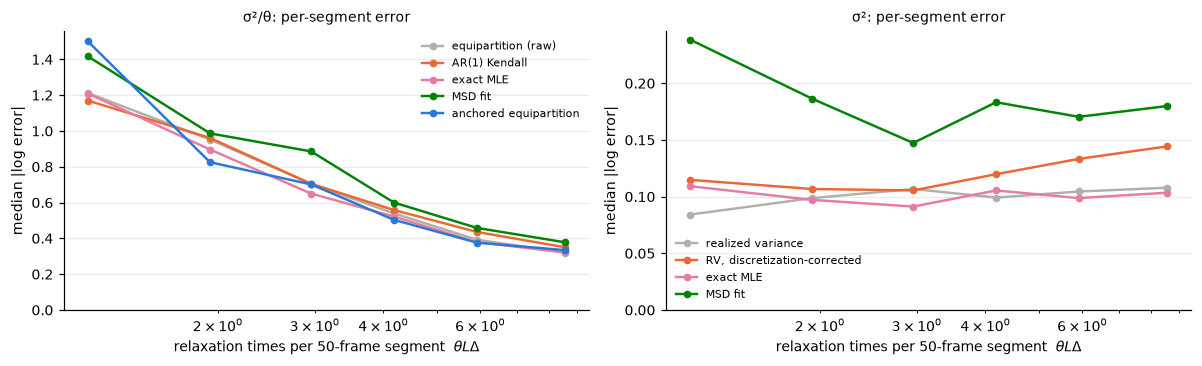

In [11]:
bins = np.array([0.9, 1.5, 2.5, 3.5, 5, 7, 10.5])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (key, EST, methods, title) in zip(axes, [
        ('R', R_EST, ['均分 (未校正)', 'AR(1)-Kendall', '精确 MLE', 'MSD 拟合', '锚定均分'], 'σ²/θ'),
        ('S2', S_EST, ['实现方差 RV', '锚定均分 (RV 校正)', '精确 MLE', 'MSD 拟合'], 'σ²')]):
    thL = np.concatenate([SEG[n]['theta'] * L * DT for n in names])
    idx = np.digitize(thL, bins) - 1
    cen = np.sqrt(bins[:-1] * bins[1:])
    colors = ['#b0b0aa', '#eb6834', '#e87ba4', '#008300', '#2a78d6', '#3a3a38']
    for m, col in zip(methods, colors):
        err = np.concatenate([np.abs(np.log(np.clip(EST[n][m], 1e-12, None) / SEG[n][key])) for n in names])
        med = [np.median(err[idx == b]) if np.any(idx == b) else np.nan for b in range(len(cen))]
        ax.plot(cen, med, marker='o', ms=4, color=col, ls='-',
                label={'均分 (未校正)': 'equipartition (raw)', 'AR(1)-Kendall': 'AR(1) Kendall', '精确 MLE': 'exact MLE',
                       'MSD 拟合': 'MSD fit', '锚定均分': 'anchored equipartition',
                       '实现方差 RV': 'realized variance', '锚定均分 (RV 校正)': 'RV, discretization-corrected'}[m])
    ax.set_xscale('log'); ax.set_xlabel(r'relaxation times per 50-frame segment  $\theta L\Delta$')
    ax.set_ylabel('median |log error|'); ax.set_title(f'{title}: per-segment error', fontsize=9); ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

### 6.4 片段估计随时间的变化

每个点是一个 50 帧片段的估计（32 条轨迹 × 20 段），实线为同一时间段 32 个片段的中位数，黑线为真值。

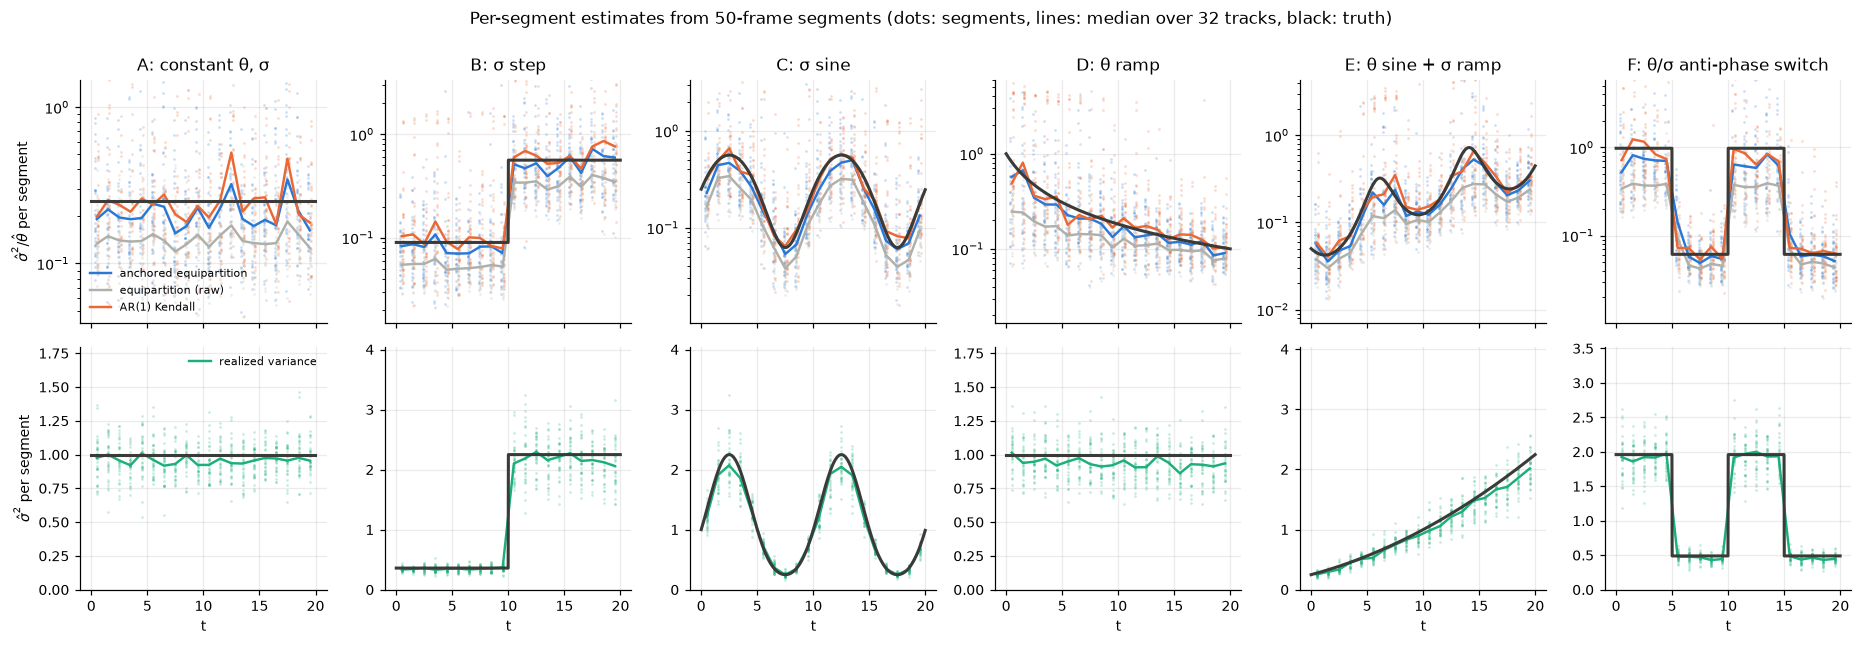

In [12]:
SHOW = [('锚定均分', '#2a78d6', 'anchored equipartition'), ('均分 (未校正)', '#b0b0aa', 'equipartition (raw)'),
        ('AR(1)-Kendall', '#eb6834', 'AR(1) Kendall')]
fig, axes = plt.subplots(2, 6, figsize=(17, 5.8), sharex=True)
for j, name in enumerate(names):
    tm = SEG[name]['t_mid']; order = np.argsort(tm)
    uniq = np.unique(tm)
    ax = axes[0, j]
    for m, col, lab in SHOW:
        est = R_EST[name][m]
        ax.scatter(tm + (SHOW.index((m, col, lab)) - 1) * 0.12, est, s=3, color=col, alpha=0.25, lw=0)
        ax.plot(uniq, [np.median(est[tm == u]) for u in uniq], color=col, lw=1.6, label=lab)
    ax.plot(t_grid, DATA[name]['sigma'] ** 2 / DATA[name]['theta'], color=C_TRUE, lw=2)
    R = DATA[name]['sigma'] ** 2 / DATA[name]['theta']
    ax.set_yscale('log'); ax.set_ylim(R.min() / 6, R.max() * 6); ax.set_title(EN[name])
    ax = axes[1, j]
    for m, col, lab in [('实现方差 RV', '#1baf7a', 'realized variance')]:
        est = S_EST[name][m]
        ax.scatter(tm, est, s=3, color=col, alpha=0.25, lw=0)
        ax.plot(uniq, [np.median(est[tm == u]) for u in uniq], color=col, lw=1.6, label=lab)
    ax.plot(t_grid, DATA[name]['sigma'] ** 2, color=C_TRUE, lw=2)
    ax.set_ylim(0, 1.8 * (DATA[name]['sigma'] ** 2).max()); ax.set_xlabel('t')
axes[0, 0].set_ylabel(r'$\hat\sigma^2/\hat\theta$ per segment'); axes[1, 0].set_ylabel(r'$\hat\sigma^2$ per segment')
axes[0, 0].legend(fontsize=7, loc='lower left'); axes[1, 0].legend(fontsize=7)
fig.suptitle('Per-segment estimates from 50-frame segments (dots: segments, lines: median over 32 tracks, black: truth)', y=1.0)
fig.tight_layout(); plt.show()

### 6.5 单条轨迹的 $\sigma^2$ 与 $\sigma^2/\theta$

每个情景取一条测试轨迹，只用它自己的数据：

- **阶梯线**：把轨迹切成 20 个 50 帧片段，每段一个估计。$\sigma^2$ 用精确 MLE，$\sigma^2/\theta$ 用锚定均分（蓝）和 AR(1)-Kendall（橙）；灰色为未校正均分，用来展示有限窗口偏差；
- **细线**：50 帧滑动窗口（逐帧移动）的锚定均分 / 精确 MLE，给出连续曲线；
- **阴影带**：由 5.1 节的模拟精度表，按每段自己估计出的 $\hat\theta L\Delta$ 查得的典型误差范围 $\hat q\cdot e^{\pm\,\text{|log| 误差}}$。**它不使用任何真值**，实际数据上也可以这样给每段加误差带；
- 黑线为真值。

$\sigma^2/\theta$ 使用对数坐标。

误差带表示“典型”（中位）误差，所以理想情况下约一半片段的真值落在带内。下面代码会在全部片段上检查这一点：实测覆盖率为 σ² 51%、σ²/θ 52%（各情景 44%–58%），说明按 $\hat\theta L\Delta$ 查表得到的误差带是校准良好的。若需要约 90% 的覆盖，可把带宽放大约 2.5 倍（对正态分布，90% 分位约为中位 |误差| 的 2.44 倍，这里只是近似）。

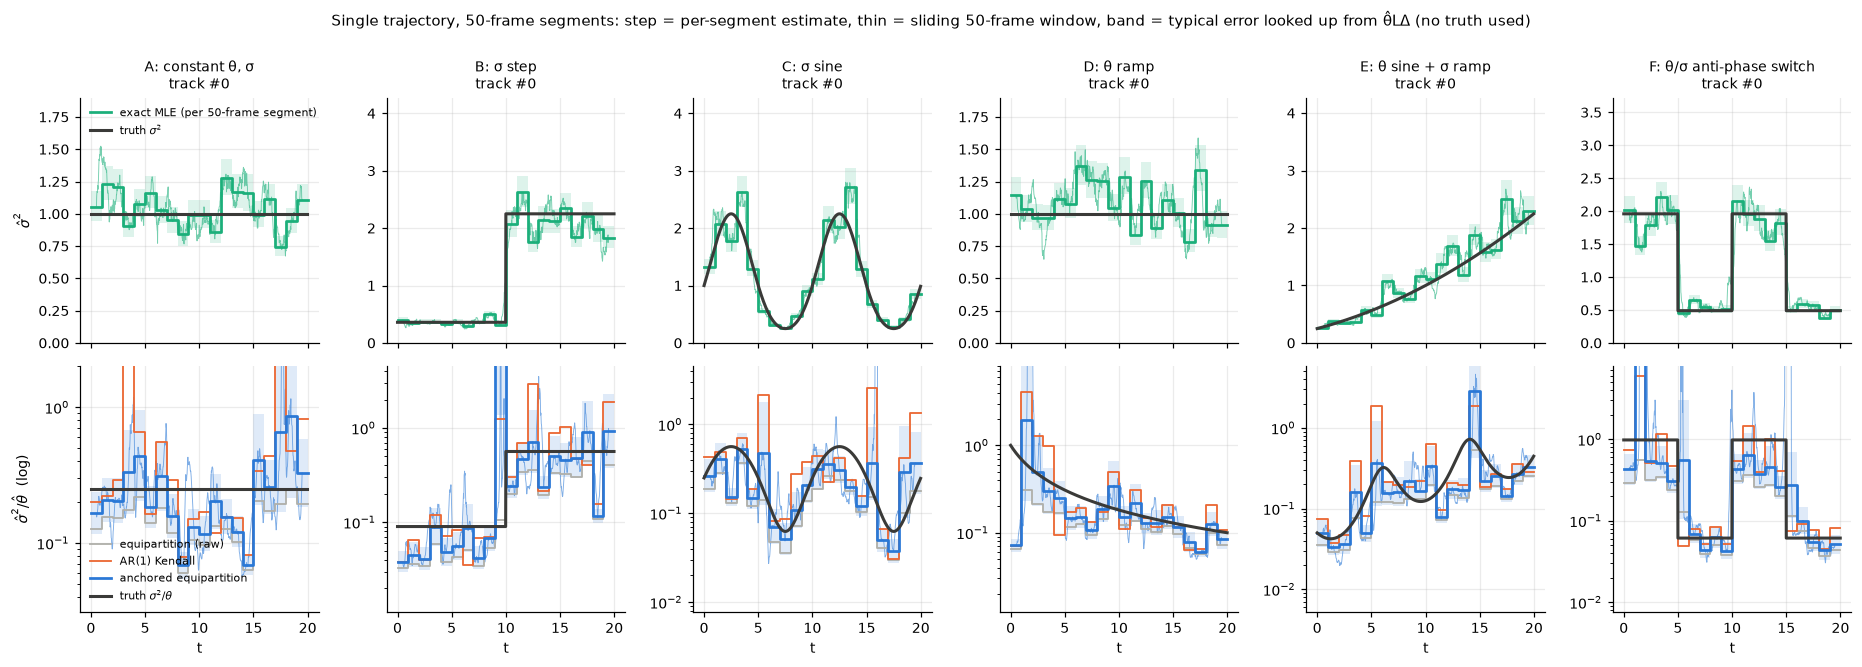

误差带覆盖真值的片段比例（理想约 50%）： {'σ²': '51%', 'σ²/θ': '52%'} | 各情景 σ²/θ： {'A: constant θ, σ': '54%', 'B: σ step': '58%', 'C: σ sine': '57%', 'D: θ ramp': '48%', 'E: θ sine + σ ramp': '52%', 'F: θ/σ anti-phase switch': '44%'}


In [13]:
ACC_TAB = acc.pivot_table(index='θLΔ', columns=['量', '方法'], values='|log| 误差')
def typical_err(q, method, thL):
    """按 θ̂LΔ 在模拟精度表中插值得到的典型 |log| 误差"""
    col = ACC_TAB[(q, method)]
    return np.interp(np.log(np.clip(thL, col.index.min(), col.index.max())), np.log(col.index.values), col.values)

def sliding_segments(X1):
    """单条轨迹 (T,2) -> 所有 50 帧滑动窗口 (T-L+1, L, 2)"""
    return np.lib.stride_tricks.sliding_window_view(X1, L, axis=0).transpose(0, 2, 1)

TRACK = 0
n_seg = T_LEN // L
seg_edges = np.arange(n_seg + 1) * L * DT
step = lambda v: np.r_[v, v[-1]]
fig, axes = plt.subplots(2, 6, figsize=(17, 6), sharex=True)
for j, name in enumerate(names):
    d = DATA[name]
    idx = np.arange(TRACK * n_seg, (TRACK + 1) * n_seg)              # 该轨迹的 20 个片段
    Xs = SEG[name]['X'][idx]
    rv = (np.diff(Xs, axis=1) ** 2).mean(axis=(1, 2))
    R_anc, _, th_anc = anchored(Xs, rv)
    R_ar = ar1_kendall(Xs)
    R_raw = 2 * Xs.var(axis=1, ddof=1).mean(axis=1)
    _, S2_mle = ou_mle(Xs)
    thL = th_anc * L * DT
    eR, eS = typical_err('σ²/θ', '锚定均分', thL), typical_err('σ²', '精确 MLE', thL)

    # 50 帧滑动窗口（窗口中心对应时间）
    W = sliding_segments(d['X'][TRACK])
    rv_w = (np.diff(W, axis=1) ** 2).mean(axis=(1, 2))
    R_w = anchored(W, rv_w)[0]
    S2_w = ou_mle(W)[1]
    t_w = (np.arange(len(W)) + (L - 1) / 2) * DT

    ax = axes[0, j]
    ax.fill_between(seg_edges, step(S2_mle * np.exp(-eS)), step(S2_mle * np.exp(eS)), step='post', color='#1baf7a', alpha=0.15, lw=0)
    ax.plot(t_w, S2_w, color='#1baf7a', lw=0.6, alpha=0.6)
    ax.step(seg_edges, step(S2_mle), where='post', color='#1baf7a', lw=1.8, label='exact MLE (per 50-frame segment)')
    ax.plot(t_grid, d['sigma'] ** 2, color=C_TRUE, lw=2, label=r'truth $\sigma^2$')
    ax.set_ylim(0, 1.9 * (d['sigma'] ** 2).max()); ax.set_title(f'{EN[name]}\ntrack #{TRACK}', fontsize=9)

    ax = axes[1, j]
    ax.fill_between(seg_edges, step(R_anc * np.exp(-eR)), step(R_anc * np.exp(eR)), step='post', color='#2a78d6', alpha=0.15, lw=0)
    ax.plot(t_w, R_w, color='#2a78d6', lw=0.6, alpha=0.6)
    ax.step(seg_edges, step(R_raw), where='post', color='#b0b0aa', lw=1.2, label='equipartition (raw)')
    ax.step(seg_edges, step(R_ar), where='post', color='#eb6834', lw=1.2, label='AR(1) Kendall')
    ax.step(seg_edges, step(R_anc), where='post', color='#2a78d6', lw=1.8, label='anchored equipartition')
    R = d['sigma'] ** 2 / d['theta']
    ax.plot(t_grid, R, color=C_TRUE, lw=2, label=r'truth $\sigma^2/\theta$')
    ax.set_yscale('log'); ax.set_ylim(R.min() / 8, R.max() * 8); ax.set_xlabel('t')
axes[0, 0].set_ylabel(r'$\hat\sigma^2$'); axes[1, 0].set_ylabel(r'$\hat\sigma^2/\hat\theta$  (log)')
axes[0, 0].legend(fontsize=7, loc='upper left'); axes[1, 0].legend(fontsize=7, loc='lower left')
fig.suptitle('Single trajectory, 50-frame segments: step = per-segment estimate, thin = sliding 50-frame window, '
             'band = typical error looked up from θ̂LΔ (no truth used)', y=1.0, fontsize=10)
fig.tight_layout(); plt.show()

# 误差带的校准检查：误差带取的是“中位”|log| 误差，理想情况下应覆盖约 50% 的片段的真值
cov = {'σ²': [], 'σ²/θ': []}
for name in names:
    Xs = SEG[name]['X']
    rv = (np.diff(Xs, axis=1) ** 2).mean(axis=(1, 2))
    R_anc, _, th_anc = anchored(Xs, rv)
    _, S2_mle = ou_mle(Xs)
    thL = th_anc * L * DT
    cov['σ²/θ'].append(np.mean(np.abs(np.log(R_anc / SEG[name]['R'])) <= typical_err('σ²/θ', '锚定均分', thL)))
    cov['σ²'].append(np.mean(np.abs(np.log(S2_mle / SEG[name]['S2'])) <= typical_err('σ²', '精确 MLE', thL)))
print('误差带覆盖真值的片段比例（理想约 50%）：', {k: f'{np.mean(v):.0%}' for k, v in cov.items()},
      '| 各情景 σ²/θ：', {EN[n]: f'{c:.0%}' for n, c in zip(names, cov['σ²/θ'])})

## 7. 结论与建议

以下数字来自本 notebook：5.1 节的纯模拟，以及 32 条测试轨迹 × 20 个片段（每个情景 640 个 50 帧片段）。

**1. $\sigma^2$：50 帧足够，单片段误差约 10%。**

- **精确 MLE** 在所有 $\theta$ 下都几乎无偏（约 +3%），推荐作为首选。
- **实现方差 RV** 在 $\theta\Delta$ 较小时同样好，但它测的是单步方差，$\theta$ 大时会低估：模拟中 $\theta L\Delta=16$ 时低估约 15%，$=32$ 时低估约 27%。
- MSD 拟合明显更差（约 18%）。

**2. $\sigma^2/\theta$：单片段精度主要由“每段包含的松弛时间数” $\theta L\Delta$ 决定，而不是由方法决定。**

| $\theta L\Delta$ | 典型误差（最好的方法） | 能否使用 |
|---|---|---|
| ≤ 1 | 4 倍以上 | 不可用 |
| 2 | 约 2.4 倍 | 只能看数量级 |
| 4 | 约 1.6 倍 | 勉强 |
| 8 | 约 1.35 倍（35%） | 可用 |
| ≥ 16 | 约 20% 或更好 | 较好 |

原因很直接：50 帧里只有几个松弛时间，就只有几个独立的“位置样本”，样本方差本身的抽样误差就很大。即使 $\sigma^2$ 完全已知（表中 `真 σ²` 参考列），误差也降不下来。

**3. 方法选择（测试集，6 个情景平均的单片段 $|\log|$ 误差 / 偏差）**

| 方法 | $|\log|$ 误差 | 偏差 | 建议 |
|---|---|---|---|
| 均分（未校正） | 0.53 | −0.51（低估约 40%） | **不要用**，有限窗口偏差太大 |
| 精确 MLE | 0.51 | −0.49 | **不要直接用**，小样本下 $\hat\theta$ 系统性偏大 |
| MSD 拟合 | 0.57 | −0.16 | 较差 |
| AR(1)-Kendall | 0.53 | ≈ 0 | 中位数无偏，适合做多片段汇总 |
| **锚定均分** | **0.48** | −0.16 | 单片段误差最低 |

**4. 汇总多个片段能大幅提高精度。** 6.4 节的图中，同一时间段 32 个片段的中位数（实线）几乎与真值重合。如果实验中能把若干 50 帧片段归为同一条件（同一时间窗、同一样品），应在**对数空间**取中位数或平均，误差大约按 $1/\sqrt{n}$ 下降。做汇总时优先用 **AR(1)-Kendall**，因为它的中位数无偏，汇总后不会残留系统偏差。

**5. SPINN 在 50 帧场景下的作用有限。**

- 当前配置需要 100 帧窗口，不能直接处理 50 帧轨迹。
- 即使借助长轨迹上下文（带 `*` 的结果），它在 $\sigma^2$ 和 $\sigma^2/\theta$ 上也没有优于经典方法。
- 如果仍想使用 SPINN，需要用 `encoder_length=25, pred_length=25` 重新训练，再做同样的对比。

**6. 推荐的实验流程（每个 50 帧片段）**

1. 用精确 MLE 估计 $\hat\sigma^2$；
2. 用锚定均分估计 $\widehat{\sigma^2/\theta}$ 和 $\hat\theta$；
3. 计算 $\hat\theta L\Delta$，对照 5.1 节的表给出误差范围。$\hat\theta L\Delta<2$ 的片段只报告 $\sigma^2$，不报告 $\sigma^2/\theta$；
4. 如果有多个同条件片段，用 AR(1)-Kendall 的对数中位数做汇总。